In [1]:
from pathlib import Path

# Project root — adjust once, use everywhere
BASE_DIR = Path(r"D:\code\mf-analysis")

DATA_RAW = BASE_DIR / "data" / "raw"
DATA_PROCESSED = BASE_DIR / "data" / "processed"
DB_PATH = BASE_DIR / "data" / "db" / "bluestockmf.db"
REPORTS_DIR = BASE_DIR / "reports"

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sqlalchemy import create_engine

engine = create_engine(f"sqlite:///{DB_PATH}")

fund_master_csv = DATA_RAW / "01_fund_master.csv"
nav_csv = DATA_RAW / "02_daily_nav.csv"

dim_date = pd.read_sql("SELECT * FROM dim_date", engine, parse_dates=["full_date"])
fund_master = pd.read_sql("SELECT * FROM dim_fund", engine)          # <-- was missing
txn_raw = pd.read_csv(DATA_RAW / "08_investor_transactions.csv", parse_dates=["transaction_date"])
performance = pd.read_sql("SELECT * FROM fact_performance", engine)

nav = pd.read_sql("SELECT * FROM fact_nav", engine)

if "full_date" not in nav.columns:
    nav = nav.merge(dim_date[["date_id","full_date"]], on="date_id", how="left")

if "scheme_name" not in nav.columns:
    nav = nav.merge(fund_master[["amfi_code","scheme_name","category"]], on="amfi_code", how="left")

# Compute daily returns on trading days only (lesson learned from Day 4)
nav = nav[nav["full_date"].dt.dayofweek < 5].copy()
nav = nav.sort_values(["amfi_code","full_date"])
nav["daily_return"] = nav.groupby("amfi_code")["nav"].pct_change()

print("Setup complete:", nav.shape)

Setup complete: (46000, 8)


In [3]:
var_results = []

for code in fund_master["amfi_code"]:
    fund_returns = nav[nav["amfi_code"]==code]["daily_return"].dropna()
    scheme_name = fund_master[fund_master["amfi_code"]==code]["scheme_name"].iloc[0]
    
    if len(fund_returns) < 30:
        continue
    
    var_95 = np.percentile(fund_returns, 5)
    cvar_95 = fund_returns[fund_returns <= var_95].mean()
    
    var_results.append({
        "amfi_code": code,
        "scheme_name": scheme_name,
        "var_95_pct": round(var_95 * 100, 4),
        "cvar_95_pct": round(cvar_95 * 100, 4)
    })

var_df = pd.DataFrame(var_results).sort_values("var_95_pct")
print(var_df.head(10))
var_df.to_csv(REPORTS_DIR / "var_cvar_report.csv", index=False)

    amfi_code                                        scheme_name  var_95_pct  \
22     119599          SBI Small Cap Fund - Direct Plan - Growth     -2.6859   
17     119095             Axis Small Cap Fund - Regular - Growth     -2.6188   
4      101207             ABSL Small Cap Fund - Regular - Growth     -2.6021   
11     118634     Nippon India Small Cap Fund - Regular - Growth     -2.5438   
21     119598         SBI Small Cap Fund - Regular Plan - Growth     -2.4507   
39     149324              DSP Small Cap Fund - Regular - Growth     -2.3483   
7      102886                UTI Mid Cap Fund - Regular - Growth     -1.9220   
2      100033  HDFC Mid-Cap Opportunities Fund - Regular - Gr...     -1.9034   
25     120505           ICICI Pru Midcap Fund - Regular - Growth     -1.8892   
16     119094                Axis Midcap Fund - Regular - Growth     -1.8480   

    cvar_95_pct  
22      -3.2384  
17      -3.1667  
4       -3.2459  
11      -3.2304  
21      -3.0595  
39      -3.

In [4]:
print(nav.columns.tolist())

['nav_id', 'amfi_code', 'date_id', 'nav', 'full_date', 'scheme_name', 'category', 'daily_return']


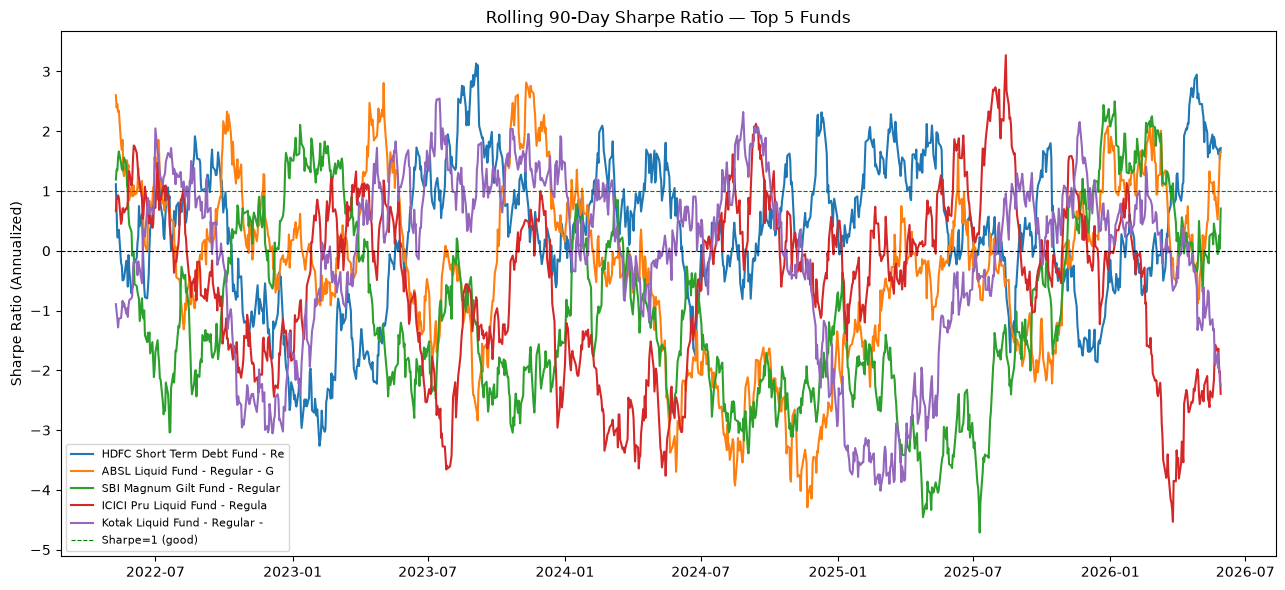

In [5]:
top5_codes = performance.nlargest(5, "sharpe_ratio")["amfi_code"].tolist()
top5_names = fund_master[fund_master["amfi_code"].isin(top5_codes)]["scheme_name"].tolist()

rf_daily = 0.065 / 252

plt.figure(figsize=(13,6))

for code, name in zip(top5_codes, top5_names):
    fund_returns = nav[nav["amfi_code"]==code].set_index("full_date")["daily_return"]
    
    rolling_sharpe = (
        (fund_returns.rolling(90).mean() - rf_daily) /
        fund_returns.rolling(90).std()
    ) * np.sqrt(252)
    
    plt.plot(rolling_sharpe.index, rolling_sharpe.values, label=name[:30])

plt.axhline(0, color="black", linestyle="--", linewidth=0.8)
plt.axhline(1, color="green", linestyle="--", linewidth=0.8, label="Sharpe=1 (good)")
plt.title("Rolling 90-Day Sharpe Ratio — Top 5 Funds")
plt.ylabel("Sharpe Ratio (Annualized)")
plt.legend(fontsize=8)
plt.tight_layout()
plt.savefig(REPORTS_DIR / "rolling_sharpe_chart.png", dpi=150)
plt.show()

In [6]:
first_txn = txn_raw.groupby("investor_id")["transaction_date"].min().reset_index()
first_txn.columns = ["investor_id", "first_txn_date"]
first_txn["cohort_year"] = first_txn["first_txn_date"].dt.year

txn_enriched = txn_raw.merge(first_txn[["investor_id","cohort_year"]], on="investor_id", how="left")
sip_only = txn_enriched[txn_enriched["transaction_type"]=="SIP"]

cohort_analysis = sip_only.groupby("cohort_year").agg(
    avg_sip_amount=("amount_inr", "mean"),
    total_invested=("amount_inr", "sum"),
    num_investors=("investor_id", "nunique")
).reset_index()

top_fund_per_cohort = (
    txn_enriched.groupby(["cohort_year","amfi_code"])
    .size().reset_index(name="txn_count")
    .sort_values(["cohort_year","txn_count"], ascending=[True,False])
    .groupby("cohort_year").first().reset_index()
    .merge(fund_master[["amfi_code","scheme_name"]], on="amfi_code")
)[["cohort_year","scheme_name"]]

cohort_analysis = cohort_analysis.merge(top_fund_per_cohort, on="cohort_year", how="left")
cohort_analysis.columns = ["cohort_year","avg_sip_amount","total_invested","num_investors","top_fund"]
print(cohort_analysis)
cohort_analysis.to_csv(REPORTS_DIR / "cohort_analysis.csv", index=False)

   cohort_year  avg_sip_amount  total_invested  num_investors  \
0         2024    10996.885825       214978121           4624   
1         2025    13505.209581         2255370            138   

                                            top_fund  
0  Mirae Asset Emerging Bluechip Fund - Regular -...  
1          SBI Small Cap Fund - Direct Plan - Growth  


In [7]:
sip_txns = txn_raw[txn_raw["transaction_type"]=="SIP"].sort_values(
    ["investor_id","transaction_date"])

sip_gaps = sip_txns.groupby("investor_id").filter(lambda x: len(x) >= 6)

sip_gaps = sip_gaps.copy()
sip_gaps["gap_days"] = sip_gaps.groupby("investor_id")["transaction_date"].diff().dt.days

avg_gap = sip_gaps.groupby("investor_id")["gap_days"].mean().reset_index()
avg_gap.columns = ["investor_id","avg_gap_days"]
avg_gap["at_risk"] = avg_gap["avg_gap_days"] > 35

print("Total investors with 6+ SIPs:", len(avg_gap))
print("At-risk investors (gap > 35 days):", avg_gap["at_risk"].sum())
print(avg_gap.sort_values("avg_gap_days", ascending=False).head(10))
avg_gap.to_csv(REPORTS_DIR / "sip_continuity.csv", index=False)

Total investors with 6+ SIPs: 1362
At-risk investors (gap > 35 days): 1332
     investor_id  avg_gap_days  at_risk
506    INV001890         102.6     True
323    INV001156         102.4     True
1188   INV004296         102.2     True
910    INV003325         101.0     True
150    INV000522         100.8     True
183    INV000608         100.2     True
503    INV001883          99.2     True
576    INV002166          99.2     True
380    INV001367          99.0     True
406    INV001491          98.8     True


In [8]:
perf_enriched = performance.merge(fund_master[["amfi_code","scheme_name"]], on="amfi_code")

def recommend_funds(risk_appetite):
    risk_map = {
        "Low": ["Low"],
        "Moderate": ["Moderate"],
        "High": ["High", "Very High"]
    }
    
    if risk_appetite not in risk_map:
        print("Invalid input. Choose: Low, Moderate, or High")
        return
    
    valid_grades = risk_map[risk_appetite]
    filtered = perf_enriched[perf_enriched["risk_grade"].isin(valid_grades)]
    top3 = filtered.nlargest(3, "sharpe_ratio")[["scheme_name","sharpe_ratio","risk_grade","return_3yr_pct"]]
    
    print(f"\nTop 3 Fund Recommendations for {risk_appetite} Risk Appetite:")
    print(top3.to_string(index=False))
    return top3

recommend_funds("Low")
recommend_funds("Moderate")
recommend_funds("High")


Top 3 Fund Recommendations for Low Risk Appetite:
                             scheme_name  sharpe_ratio risk_grade  return_3yr_pct
ICICI Pru Liquid Fund - Regular - Growth          7.68        Low            7.68
    Kotak Liquid Fund - Regular - Growth          6.18        Low            6.18
     ABSL Liquid Fund - Regular - Growth          5.14        Low            5.14

Top 3 Fund Recommendations for Moderate Risk Appetite:
                                  scheme_name  sharpe_ratio risk_grade  return_3yr_pct
    HDFC Top 100 Fund - Regular Plan - Growth          1.06   Moderate           14.84
Mirae Asset Large Cap Fund - Regular - Growth          1.06   Moderate           14.81
    ICICI Pru Bluechip Fund - Direct - Growth          1.03   Moderate           14.41

Top 3 Fund Recommendations for High Risk Appetite:
                                  scheme_name  sharpe_ratio risk_grade  return_3yr_pct
Kotak Emerging Equity Fund - Regular - Growth          0.96       High        

,scheme_name,sharpe_ratio,risk_grade,return_3yr_pct
21,Kotak Emerging Equity Fund - Regular - Growth,0.96,High,18.23
12,ICICI Pru Midcap Fund - Regular - Growth,0.95,High,18.08
2,SBI Small Cap Fund - Regular Plan - Growth,0.94,Very High,23.39


In [9]:
# Load raw fund master which has the correct broad category (Equity/Debt/Hybrid)
fund_master_raw = pd.read_csv(DATA_RAW / "01_fund_master.csv")
print(fund_master_raw[["amfi_code","category"]].head())
print("Unique categories:", fund_master_raw["category"].unique())

# Reload holdings fresh
holdings = pd.read_sql("SELECT * FROM fact_portfolio", engine)

# Merge using raw fund master's broad category
holdings = holdings.merge(
    fund_master_raw[["amfi_code","category"]], 
    on="amfi_code", how="left")

print("Categories in holdings:", holdings["category"].unique())

# Now filter to Equity only
equity_holdings = holdings[holdings["category"]=="Equity"]
print("Equity holdings shape:", equity_holdings.shape)

   amfi_code category
0     119551   Equity
1     119552   Equity
2     119598   Equity
3     119599   Equity
4     119120     Debt
Unique categories: <StringArray>
['Equity', 'Debt']
Length: 2, dtype: str
Categories in holdings: <StringArray>
['Equity']
Length: 1, dtype: str
Equity holdings shape: (322, 6)


    amfi_code    hhi_score                                        scheme_name
11     119092  2064.889657              Axis Bluechip Fund - Regular - Growth
3      101207  2007.405761             ABSL Small Cap Fund - Regular - Growth
18     119599  1747.509600          SBI Small Cap Fund - Direct Plan - Growth
4      102885  1747.090200         UTI Nifty 50 Index Fund - Regular - Growth
7      118632  1682.309009     Nippon India Large Cap Fund - Regular - Growth
29     148568  1679.633210  Mirae Asset Emerging Bluechip Fund - Regular -...
21     120505  1575.073508           ICICI Pru Midcap Fund - Regular - Growth
22     120506  1537.321010  ICICI Pru Value Discovery Fund - Regular - Growth
27     125498  1524.139800  HDFC Mid-Cap Opportunities Fund - Direct - Growth
23     120841  1496.504184             Kotak Bluechip Fund - Regular - Growth
30     148569  1494.561965      Mirae Asset Tax Saver Fund - Regular - Growth
1      100033  1475.922600  HDFC Mid-Cap Opportunities Fund - Re

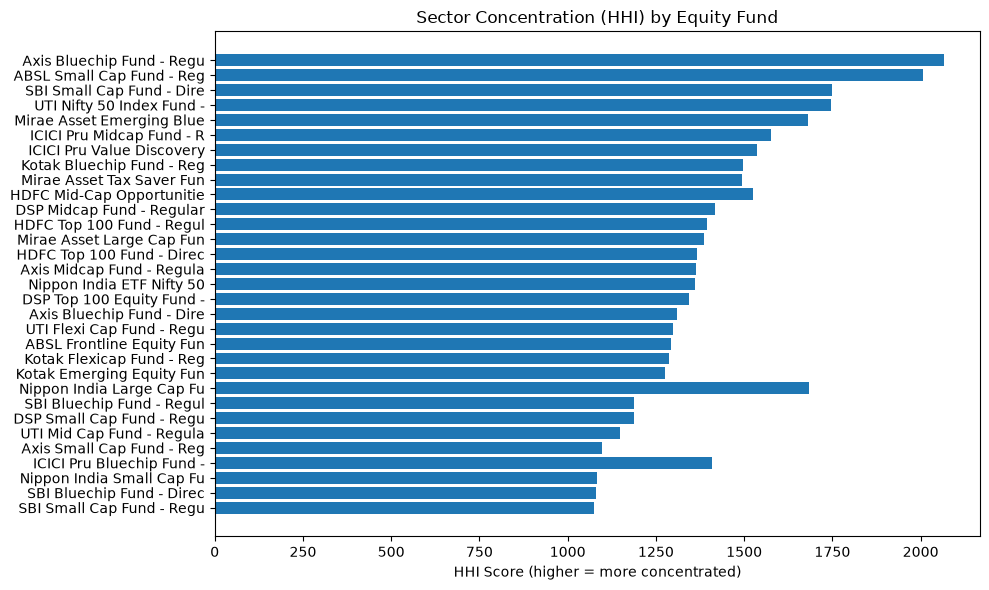

In [10]:
def calculate_hhi(weights):
    weights_pct = weights / weights.sum() * 100
    return (weights_pct ** 2).sum()

hhi_results = holdings.groupby("amfi_code")["weight_pct"].apply(
    calculate_hhi).reset_index()
hhi_results.columns = ["amfi_code","hhi_score"]

hhi_results = hhi_results.merge(
    fund_master_raw[["amfi_code","scheme_name"]], 
    on="amfi_code")
hhi_results = hhi_results.sort_values("hhi_score", ascending=False)

print(hhi_results)
hhi_results.to_csv(REPORTS_DIR / "sector_hhi.csv", index=False)

plt.figure(figsize=(10,6))
plt.barh(
    hhi_results["scheme_name"].str[:25].iloc[::-1], 
    hhi_results["hhi_score"].iloc[::-1])
plt.title("Sector Concentration (HHI) by Equity Fund")
plt.xlabel("HHI Score (higher = more concentrated)")
plt.tight_layout()
plt.savefig(REPORTS_DIR / "sector_hhi_chart.png", dpi=150)
plt.show()